In [46]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.lines import Line2D

In [1]:
%reset -f

In [3]:
os.chdir(r'C:\Users\ANDILATT\OneDrive\Data_analysis')

In [12]:
#load all datasets
#
df2 = pd.read_excel("Data_source_paper_biogeosciences.xlsx", sheet_name="SimREF")
df2["time_counter"] = pd.to_datetime(df2["time_counter"])
df2 = df2[df2["time_counter"].dt.year < 2024]
df2.set_index("time_counter", inplace=True)
df2.head()

,Rain,LAI_Tree_obs,LAI_Tree_orch,LAI_Crop_obs,LAI_Crop_orch
time_counter,,,,,
2018-01-01,0.0,NaN,0.627982,0.0,0.0
2018-01-02,0.0,NaN,0.627982,0.0,0.0
2018-01-03,0.0,NaN,0.627982,0.0,0.0
2018-01-04,0.0,NaN,0.627982,0.0,0.0
2018-01-05,0.0,NaN,0.627982,0.0,0.0


In [100]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

def calculate_r_squared(df, obs_col, sim_col):
    """
    Calculates the R-squared between two columns of a Pandas DataFrame.

    Args:
        df: The DataFrame containing the data.
        obs_col: The name of the observation column.
        sim_col: The name of the predicted column.

    Returns:
        The R-squared value.
    """

    # Extract relevant data, handling NaN values
    df = df.dropna(subset=[obs_col, sim_col])
    obs_y = df[obs_col].values
    sim_y = df[sim_col].values

    # Check for sufficient data points
    if len(obs_y) < 2 or len(sim_y) < 2:
        return np.nan  # Return NaN if there's insufficient data

    # Calculate linear regression and R-squared
    slope, intercept, r_value, _, _ = linregress(obs_y, sim_y)
    r_squared = r_value**2
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((obs_y - sim_y)**2))

    return r_squared, rmse

In [93]:
# Define the calibration and validation periods
calibration_start = pd.Timestamp('2018-01-01')
calibration_end = pd.Timestamp('2020-12-31')
validation_start = pd.Timestamp('2021-01-01')
validation_end = pd.Timestamp('2023-12-31')

# Create sub datasets for calibration and validation periods
calibration_data = df2[(df2.index >= calibration_start) & (df2.index <= calibration_end)]
validation_data = df2[(df2.index >= validation_start) & (df2.index <= validation_end)]

In [102]:
# Define a list of dataframes and a list of column pairs
dataframes = [calibration_data, validation_data]
column_pairs = [('LAI_Tree_obs', 'LAI_Tree_orch'), ('LAI_Crop_obs', 'LAI_Crop_orch')]

# Create an empty dictionary to store the results
results = {}

# Iterate over dataframes and column pairs
for df in dataframes:
    for col1, col2 in column_pairs:
        r_squared_result, rmse = calculate_r_squared(df, col1, col2)
        data_type = "Calibration" if df is calibration_data else "Validation"
        lai_type = "LAI tree" if "Tree" in col1 else "LAI crop"
        key = f"{data_type} {lai_type}"
        results[key] = {"R-squared": r_squared_result, "RMSE": rmse}

# Print the results from the dictionary
for key, value in results.items():
    print(f"{key} ===> R-squared: {value['R-squared']:.4f}; RMSE: {value['RMSE']:.4f}")


Calibration LAI tree ===> R-squared: 0.7750; RMSE: 0.2618
Calibration LAI crop ===> R-squared: 0.4289; RMSE: 0.2746
Validation LAI tree ===> R-squared: 0.8934; RMSE: 0.2313
Validation LAI crop ===> R-squared: 0.6415; RMSE: 0.2448


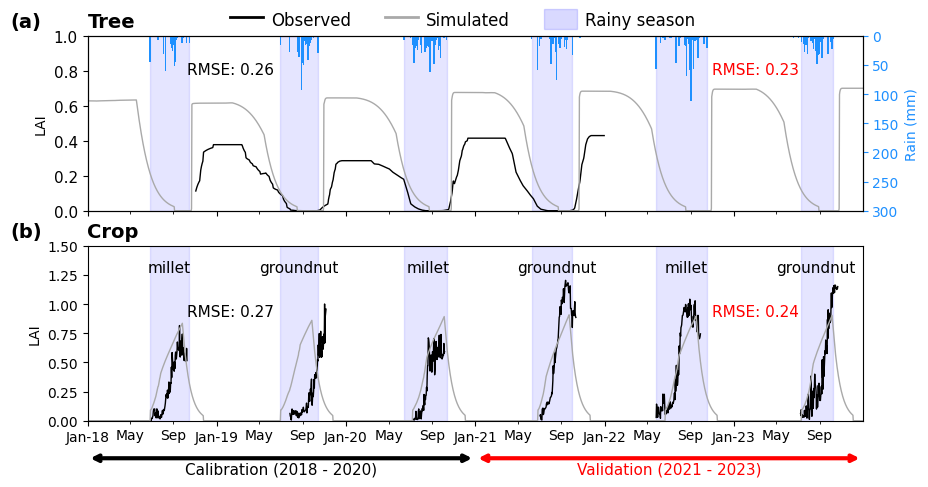

In [135]:


# Define color
color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

# Identify the start and end dates for the rainy season each year
rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create the plots with shared x-axis
fig, (ax2, ax1) = plt.subplots(2, 1, sharex=True, figsize=(10, 5))

# Add the inverted Rain on the secondary y-axis
ax3 = ax2.twinx()
ax3.invert_yaxis()
ax3.bar(df2.index, df2['Rain'], width=4, color=color_rain, label='Rain (mm)')

# Highlight the rainy periods
for start, end in rainy_seasons:
    ax1.axvspan(start, end, color='blue', alpha=0.1)
    ax2.axvspan(start, end, color='blue', alpha=0.1)

# Plot LAI_Crop_obs and LAI_Crop_orch on the first subplot
ax1.plot(df2.index, df2['LAI_Crop_obs'], lw=line_weight, label='LAI_Crop_obs', color=color_obs)
ax1.plot(df2.index, df2['LAI_Crop_orch'], lw=line_weight, label='LAI_Crop_orch', color=color_sim)

# Add crop annotations at June 1st
crops = ['millet', 'groundnut']  # Cycle through these crops
years = df2.index.year.unique()

for i, year in enumerate(years):
    crop = crops[i % len(crops)]  # Alternate between 'millet' and 'peanut'
    date = pd.Timestamp(f'{year}-08-20')
    ax1.text(date, 1.25, crop, color='black', fontsize=11, verticalalignment='bottom', horizontalalignment='center')


a_lim = df2.index.min() + pd.Timedelta(days=280)
b_lim = df2.index.max() - pd.Timedelta(days=180)
# Add MRMSE indicators
#Crop
ax1.text(a_lim, 1, f"RMSE: {results['Calibration LAI crop']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax1.text(b_lim, 1, f"RMSE: {results['Validation LAI crop']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')
#Tree
ax2.text(a_lim, 0.85, f"RMSE: {results['Calibration LAI tree']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax2.text(b_lim, 0.85, f"RMSE: {results['Validation LAI tree']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')

ax2.text(-0.1, 1.05, f'({chr(98)})', transform=ax1.transAxes, size=14, weight='bold')
ax1.text(-0.1, 1.05, f'({chr(97)})', transform=ax2.transAxes, size=14, weight='bold')
ax1.set_title("Crop", fontsize=14, loc="left", weight='bold')
ax2.set_title("Tree", fontsize=14, loc="left", weight='bold')

# Set labels and title for the first subplot
ax1.set_ylabel('LAI')
ax3.set_ylabel('Rain (mm)', color=color_rain)
ax3.tick_params(axis='y', colors=color_rain)
ax3.set_ylim(300, 0)
ax1.set_ylim(0, 1.5)
ax2.set_ylim(0, 1)

# Plot LAI_Tree_obs and LAI_Tree_orch on the second subplot
line1, = ax2.plot(df2.index, df2['LAI_Tree_obs'], lw=line_weight, label='Observed', color=color_obs)
line2, = ax2.plot(df2.index, df2['LAI_Tree_orch'], lw=line_weight, label='Simulated', color=color_sim)

# Set labels and title for the second subplot
# ax2.set_xlabel('Date')
ax2.set_ylabel('LAI')

# Create a patch for the rainy season
rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')

# Create lines for 'Observed' and 'Simulated'
line1 = Line2D([0], [0], color=color_obs, lw=2, label='Observed')  # lw (linewidth) = 2 for smaller line width
line2 = Line2D([0], [0], color=color_sim, lw=2, label='Simulated')

# Add a legend for the lines and patch
fig.legend([line1, line2, rain_patch],
           ['Observed', 'Simulated', 'Rainy season'],
           loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.95), frameon=False, 
           fontsize=12,
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=2.0,       
           borderpad=0.0,          
           handletextpad=0.5)


ax1.set_xlim(df2.index.min(), df2.index.max())
ax2.set_xlim(df2.index.min(), df2.index.max())

# Set x-axis ticks for Jan, May, and Sept
ax2.xaxis.set_major_locator(YearLocator())
ax2.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
ax2.xaxis.set_major_formatter(DateFormatter("%Y"))
ax2.xaxis.set_minor_formatter(DateFormatter("%b"))
# ax1.set_xlabel('Date', fontsize=11)

# Update tick label sizes
ax2.tick_params(axis='x', which='major', labelsize=9)
ax2.tick_params(axis='x', which='minor', labelsize=8)
ax2.tick_params(axis='y', labelsize=11)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
ax2.xaxis.set_major_formatter(date_form)

# Create an additional axes at the bottom for drawing the arrows
bbox = ax1.get_position()
arrow_ax = fig.add_axes([bbox.x0, 0.01, bbox.width, 0.05])  # Align with ax1
arrow_ax.axis('off')

# Define start and end dates for the arrows
start_date_black = pd.Timestamp('2018-01-01')
end_date_black = pd.Timestamp('2020-12-31')
start_date_red = pd.Timestamp('2021-01-01')
end_date_red = pd.Timestamp('2023-12-31')

# Draw arrows using date positions directly on the new axis
arrow_ax.annotate('', xy=(start_date_black, 0.5), xytext=(end_date_black, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='black', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

arrow_ax.annotate('', xy=(start_date_red, 0.5), xytext=(end_date_red, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='red', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

# Compute the midpoints and add text below the arrows
mid_black = start_date_black + (end_date_black - start_date_black) / 2
mid_red = start_date_red + (end_date_red - start_date_red) / 2

arrow_ax.text(mid_black, 0.05, 'Calibration (2018 - 2020)',
              color='black', ha='center', va='center', fontsize=11)

arrow_ax.text(mid_red, 0.05, 'Validation (2021 - 2023)',
              color='red', ha='center', va='center', fontsize=11)

arrow_ax.set_xlim(df2.index.min(), df2.index.max())

plt.show()

In [104]:
results

{'Calibration LAI tree': {'R-squared': 0.7749804508158767,
  'RMSE': 0.2617581204198021},
 'Calibration LAI crop': {'R-squared': 0.428938119795267,
  'RMSE': 0.2745988112434029},
 'Validation LAI tree': {'R-squared': 0.893356126690539,
  'RMSE': 0.23129006451556913},
 'Validation LAI crop': {'R-squared': 0.6414536854749464,
  'RMSE': 0.24480933582682018}}

In [129]:
df2.index.min() + pd.Timedelta(days=120)

Timestamp('2018-05-01 00:00:00')

In [107]:
results["Calibration LAI tree"]["RMSE"]
results["Validation LAI tree"]["RMSE"]
results["Calibration LAI crop"]["RMSE"]
results["Validation LAI crop"]["RMSE"]

0.24480933582682018